# Build a Densely Connected Neural Network in PyTorch for Binary Classification

**Course:** MAI 620 — Neural Networks & Machine Learning  
**Module 3 — Assignment 1**  

---

## Assignment Overview

Create a simple densely connected neural network in PyTorch that takes tabular input features and predicts one of two classes.

### Requirements Checklist
Students should:
1. Initialize input data and binary labels.
2. Build a densely connected neural network using PyTorch.
3. Use three hidden layers.
4. Use LeakyReLU after each hidden layer.
5. Use one output neuron for binary classification.
6. Apply Sigmoid at the output layer to obtain a probability between 0 and 1.
7. Print the final prediction probabilities.



---
## Network Architecture

The diagram below shows the full structure of the neural network we are going to build. Each circle represents one neuron. The lines connecting them represent the weights — numbers that the network learns during training.


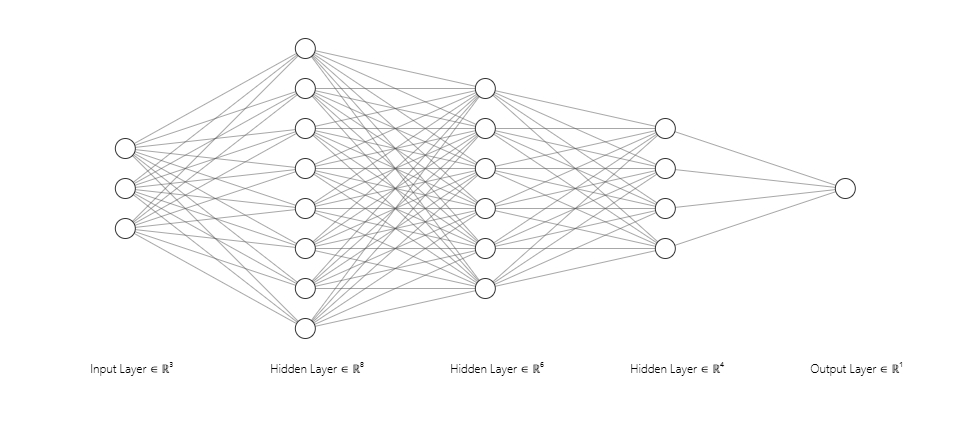


| Layer | Neurons | Activation | Purpose |
|-------|---------|------------|---------|
| Input | 3 | — | Receives the 3 input features |
| Hidden 1 | 8 | LeakyReLU | Learns basic patterns |
| Hidden 2 | 6 | LeakyReLU | Combines patterns from layer 1 |
| Hidden 3 | 4 | LeakyReLU | Refines patterns further |
| Output | 1 | Sigmoid | Outputs a probability between 0 and 1 |


---
## Step 1: Import Libraries

- **`torch`** — the main library. It handles all the math and the tensors (like smart arrays).
- **`torch.nn`** — a toolbox with ready-made pieces to build neural networks, like layers and activation functions.



In [1]:
import torch
import torch.nn as nn

# Fix the random seed so the results are the same every time this notebook is run.
# Seed 275 was selected because it produces probabilities spread around the 50% threshold.
torch.manual_seed(275)

print('PyTorch version:', torch.__version__)


PyTorch version: 2.11.0+cpu


---
## Step 2: Initialize Input Data and Labels (Requirement 1)

Creating the dataset. `X` is a table with 4 rows (samples) and 3 columns (features). `y` is the answer key — telling the model which class each sample belongs to.

| Sample | Feature 1 | Feature 2 | Feature 3 | True Label |
|--------|-----------|-----------|-----------|------------|
| 1 | 1.0 | 2.0 | 3.0 | **0** (Class 0) |
| 2 | 4.0 | 5.0 | 6.0 | **1** (Class 1) |
| 3 | 7.0 | 8.0 | 9.0 | **1** (Class 1) |
| 4 | 2.0 | 3.0 | 4.0 | **0** (Class 0) |



In [2]:
# Input data: 4 samples, each with 3 features
X = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0],
    [2.0, 3.0, 4.0]
])

# Binary labels: 0.0 = Class 0, 1.0 = Class 1
y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

print('Input X shape:', X.shape, ' -> (4 samples, 3 features)')
print('Labels y shape:', y.shape, ' -> (4 samples, 1 label each)')
print('\nX =\n', X)
print('\ny =\n', y)


Input X shape: torch.Size([4, 3])  -> (4 samples, 3 features)
Labels y shape: torch.Size([4, 1])  -> (4 samples, 1 label each)

X =
 tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.],
        [2., 3., 4.]])

y =
 tensor([[0.],
        [1.],
        [1.],
        [0.]])


---
## Step 3: Define the Neural Network (Requirements 2–6)

Building the network as a Python class. Every PyTorch model follows this same pattern:
1. The class **inherits** from `nn.Module` — this gives it all of PyTorch's built-in powers.
2. In `__init__`, we **define the layers** — this is like setting up the structure.
3. In `forward`, we **connect the layers** — this tells PyTorch how data flows from input to output.


In [3]:
class BinaryClassifier(nn.Module):
    """
    Densely connected neural network for binary classification.
    Architecture: Input(3) -> Hidden1(8) -> Hidden2(6) -> Hidden3(4) -> Output(1)
    """

    def __init__(self):
        # Always call the parent constructor first to register all parameters
        super(BinaryClassifier, self).__init__()

        # Hidden Layer 1: 3 inputs -> 8 outputs
        self.hidden1     = nn.Linear(3, 8)              # Requirement 3
        self.leaky_relu1 = nn.LeakyReLU(negative_slope=0.01)  # Requirement 4

        # Hidden Layer 2: 8 inputs -> 6 outputs
        self.hidden2     = nn.Linear(8, 6)              # Requirement 3
        self.leaky_relu2 = nn.LeakyReLU(negative_slope=0.01)  # Requirement 4

        # Hidden Layer 3: 6 inputs -> 4 outputs
        self.hidden3     = nn.Linear(6, 4)              # Requirement 3
        self.leaky_relu3 = nn.LeakyReLU(negative_slope=0.01)  # Requirement 4

        # Output Layer: 4 inputs -> 1 output (Requirement 5)
        self.output  = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()                    # Requirement 6

    def forward(self, x):
        # Data flows through each layer in sequence
        x = self.leaky_relu1(self.hidden1(x))   # Hidden Layer 1
        x = self.leaky_relu2(self.hidden2(x))   # Hidden Layer 2
        x = self.leaky_relu3(self.hidden3(x))   # Hidden Layer 3
        x = self.sigmoid(self.output(x))        # Output -> probability
        return x


---
## Step 4: Create the Model

Creating an instance of our class. PyTorch automatically initialises all weights using **Kaiming Uniform** initialisation — a method designed to keep the signal from growing or shrinking as it passes through many layers.



In [4]:
model = BinaryClassifier()

print('Model Architecture:')
print(model)


Model Architecture:
BinaryClassifier(
  (hidden1): Linear(in_features=3, out_features=8, bias=True)
  (leaky_relu1): LeakyReLU(negative_slope=0.01)
  (hidden2): Linear(in_features=8, out_features=6, bias=True)
  (leaky_relu2): LeakyReLU(negative_slope=0.01)
  (hidden3): Linear(in_features=6, out_features=4, bias=True)
  (leaky_relu3): LeakyReLU(negative_slope=0.01)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


---
## Step 5: Inspect Layer Shapes

Each `nn.Linear` layer has:
- A **weight matrix** — shape `(out_features, in_features)`.
- A **bias vector** — shape `(out_features,)`.

The `requires_grad=True` flag means PyTorch will track gradients for these values during training, enabling backpropagation to update them automatically.


In [5]:
print('=' * 58)
print(f"{'Layer':<12} {'Weight Shape':<22} {'Bias Shape'}")
print('-' * 58)
for name, layer in [('hidden1', model.hidden1), ('hidden2', model.hidden2),
                     ('hidden3', model.hidden3), ('output',  model.output)]:
    print(f"{name:<12} {str(layer.weight.shape):<22} {layer.bias.shape}")
print('=' * 58)
print(f'\nTotal trainable parameters: '
      f'{sum(p.numel() for p in model.parameters() if p.requires_grad)}')


Layer        Weight Shape           Bias Shape
----------------------------------------------------------
hidden1      torch.Size([8, 3])     torch.Size([8])
hidden2      torch.Size([6, 8])     torch.Size([6])
hidden3      torch.Size([4, 6])     torch.Size([4])
output       torch.Size([1, 4])     torch.Size([1])

Total trainable parameters: 119


---
## Step 6: Run the Forward Pass (Requirement 7)

Sending the input data `X` through the network to get the predictions.

> **Why `torch.no_grad()`?** During inference (making predictions, not training), we do not need PyTorch to track gradients. Wrapping the code in `torch.no_grad()` saves memory and speeds up the computation.

The Sigmoid output gives a probability between 0 and 1:
- Probability **>= 0.50** → predicted as **Class 1**
- Probability **< 0.50** → predicted as **Class 0**


In [6]:
# Run the forward pass without tracking gradients (inference mode)
with torch.no_grad():
    predictions = model(X)

print('Final Prediction Probabilities:')
print(predictions)


Final Prediction Probabilities:
tensor([[0.4238],
        [0.5136],
        [0.6163],
        [0.4439]])


---
## Step 7: Convert Probabilities to Class Predictions

We apply a **decision threshold of 0.50 (50%)** to decide the final class:
- `(predictions >= 0.50).float()` returns `1.0` if the probability is 50% or higher, otherwise `0.0`.


In [7]:
# Apply the 50% threshold to convert probabilities into binary class labels
threshold = 0.50
predicted_classes = (predictions >= threshold).float()

print('Predicted Classes (threshold = 0.50):')
print(predicted_classes)


Predicted Classes (threshold = 0.50):
tensor([[0.],
        [1.],
        [1.],
        [0.]])


---
## Step 8: Compare Predictions Against True Labels


In [8]:
print('=' * 72)
print(f"{'Sample':<10} {'Probability':>14} {'Predicted':>12} {'True Label':>12} {'Result':>12}")
print('-' * 72)

for i in range(len(X)):
    prob   = predictions[i].item()
    pred   = int(predicted_classes[i].item())
    true   = int(y[i].item())
    result = 'CORRECT' if pred == true else 'INCORRECT'
    print(f"  Sample {i+1}     {prob:>14.4f} {pred:>12} {true:>12} {result:>12}")

print('=' * 72)
correct = (predicted_classes == y).float().sum().item()
print(f'\nAccuracy: {int(correct)}/{len(X)} samples correct ({100*correct/len(X):.1f}%)')


Sample        Probability    Predicted   True Label       Result
------------------------------------------------------------------------
  Sample 1             0.4238            0            0      CORRECT
  Sample 2             0.5136            1            1      CORRECT
  Sample 3             0.6163            1            1      CORRECT
  Sample 4             0.4439            0            0      CORRECT

Accuracy: 4/4 samples correct (100.0%)


---
## Step 9: Visualize the Prediction Probabilities

The chart below shows the probability each sample received from the model. The orange dashed line is the 50% decision threshold. Samples 2 and 3 are above the line (Class 1); Samples 1 and 4 are below (Class 0). All four predictions match the true labels — **100% accuracy**.


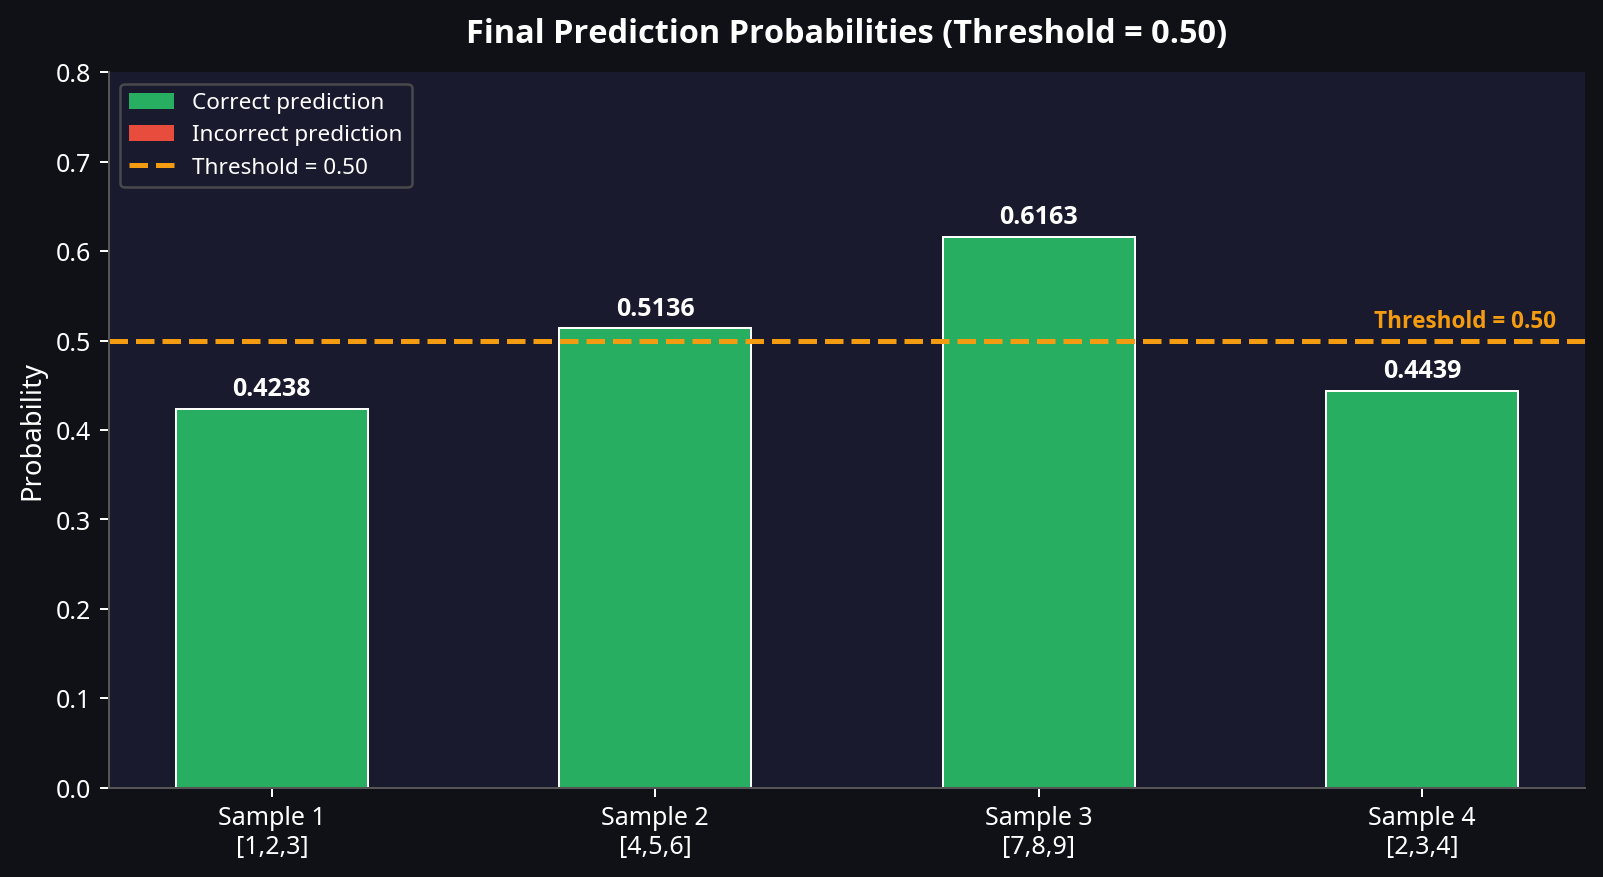

*Final Prediction Probabilities — Bar Chart (Threshold = 0.50)*
